# 08-bcr-influenza

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import tarfile
import re
import warnings
warnings.filterwarnings('ignore')

DATA = Path("data")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
metadata = pd.read_csv(DATA / "metadata.csv", dtype={"patient": str}).set_index("patient")
metadata

,sex,age,ethnicity,race
patient,,,,
09,female,25,Not Hispanic or Latino,white
15,male,29,Hispanic or Latino,white
48,male,85,Not Hispanic or Latino,white
67,female,28,Not Hispanic or Latino,white
93,female,92,Not Hispanic or Latino,white
94,female,66,Not Hispanic or Latino,white


In [ ]:
def extract_tar(tar_path: Path, dest: Path) -> Path:
  if not dest.exists():
    with tarfile.open(tar_path, "r:gz") as tf:
      tf.extractall(dest)
  return dest

def read_sample(path: Path) -> tuple[ad.AnnData, ad.AnnData]:
  cellranger_tar = next(path.glob("*_cellranger.tar.gz"))
  bcrvdj_tar = next(path.glob("*_BCRVDJ.tar.gz"))

  cellranger_dir = extract_tar(cellranger_tar, path / "cellranger")
  bcrvdj_dir = extract_tar(bcrvdj_tar, path / "BCRVDJ")
  contig_csv = next(bcrvdj_dir.glob("**/filtered_contig_annotations.csv"))

  adata_gex = sc.read_10x_mtx(cellranger_dir, var_names="gene_symbols", compressed=False)
  adata_gex.var_names_make_unique()

  adata_tcr = ir.io.read_10x_vdj(contig_csv)
  ir.pp.index_chains(adata_tcr)
  ir.tl.chain_qc(adata_tcr)

  return adata_gex, adata_tcr

def add_metadata(mdata: mu.MuData):
  cell_samples = mdata.obs_names.to_series().str.split("_", expand=True)[1]
  cell_patient = cell_samples.str.split("-", expand=True)[0]

  mdata.obs["sample"] = cell_samples
  mdata.obs["patient"] = cell_patient
  mdata.obs["days_after_vaccination"] = cell_samples.str.split("-", expand=True)[1].astype(int)
  mdata.obs["age"] = cell_patient.map(metadata["age"])
  mdata.obs["sex"] = cell_patient.map(metadata["sex"])
  mdata.obs["young"] = mdata.obs["age"] < 40
  mdata.push_obs()

In [4]:
adatas_gex = {}
adatas_tcr = {}

for sample_dir in sorted(DATA.iterdir()):
  match = re.match(r"(\d+)-(\d+)", sample_dir.name)

  if not sample_dir.is_dir() or not match:
      continue

  sample = sample_dir.name
  gex, tcr = read_sample(sample_dir)

  adatas_gex[sample] = gex
  adatas_tcr[sample] = tcr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_tcr = ad.concat(adatas_tcr, index_unique="_")

mdata = mu.MuData({"gex": adata_gex, "airr": adata_tcr})
add_metadata(mdata)
mdata

MuData object with n_obs × n_vars = 140699 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	123693 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
      layers:	None
    airr:	121533 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [5]:
mdata

MuData object with n_obs × n_vars = 140699 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	123693 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
      layers:	None
    airr:	121533 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [6]:
n_cells_all = len(set(mdata['airr'].obs.index.tolist()) & set(mdata['gex'].obs.index.tolist()))
print(f"Total number of cells: {n_cells_all}")

Total number of cells: 104527


In [7]:
adata = mdata['gex']
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
mdata

MuData object with n_obs × n_vars = 140699 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	123693 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
      var:	'mt', 'ribo', 'hb'
      layers:	None
    airr:	121533 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

In [ ]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
mdata

MuData object with n_obs × n_vars = 140699 × 33538
  obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young'
  2 modalities
    gex:	123693 × 33538
      obs:	'sample', 'patient', 'days_after_vaccination', 'age', 'sex', 'young', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
      layers:	None
    airr:	121533 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'age', 'days_after_vaccination', 'patient', 'sample', 'sex', 'young'
      obsm:	'airr', 'chain_indices'

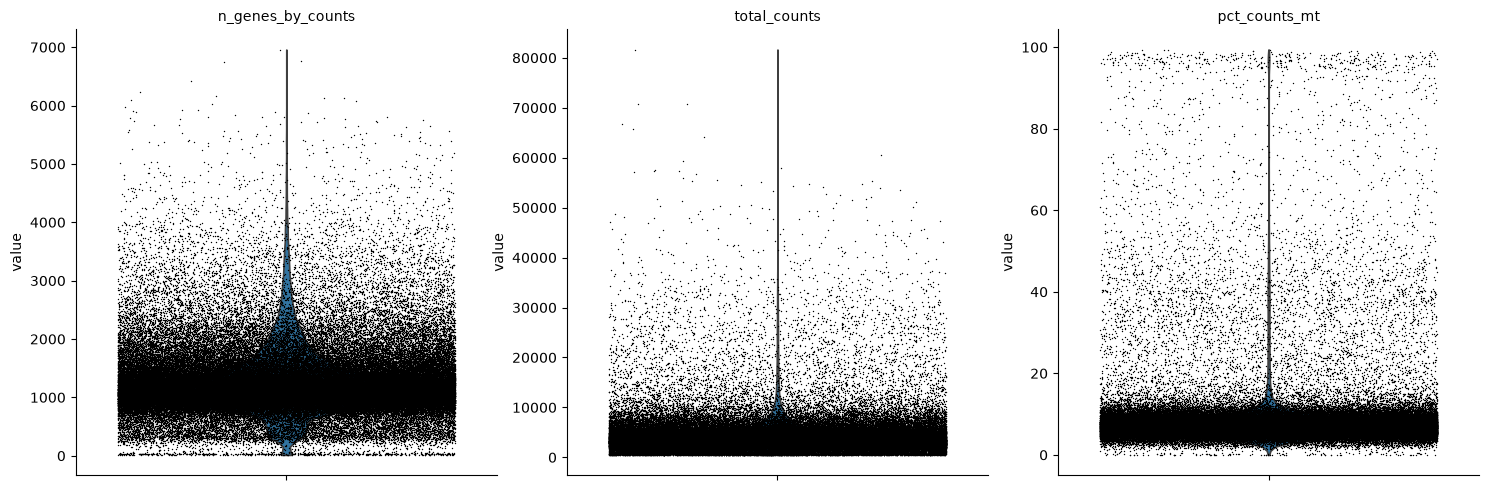

In [9]:
sc.pl.violin(
  mdata['gex'],
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  jitter=0.4,
  multi_panel=True,
)

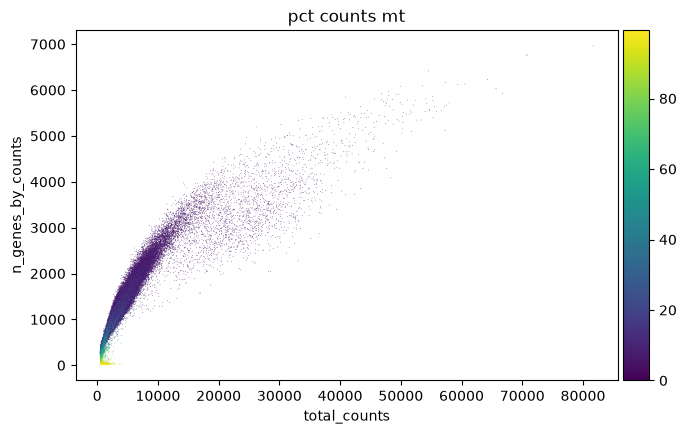

In [10]:
sc.pl.scatter(mdata['gex'], "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [11]:
sc.pp.filter_cells(mdata['gex'], min_genes=100)
sc.pp.filter_genes(mdata['gex'], min_cells=3)
mu.pp.filter_obs(mdata['gex'], 'pct_counts_mt', lambda x: x < 10)
mdata.update()
mu.pp.intersect_obs(mdata)

In [12]:
mu.pp.filter_obs(mdata, "airr:receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: x == "single pair")
mdata.update()
mu.pp.intersect_obs(mdata)

In [13]:
display(mdata['airr'].obs.groupby('receptor_subtype').count())
display(mdata['airr'].obs.groupby('chain_pairing').count())

,receptor_type,chain_pairing,age,days_after_vaccination,patient,sample,sex,young
receptor_subtype,,,,,,,,
IGH+IGK,42832,42832,42832,42832,42832,42832,42832,42832
IGH+IGL,29288,29288,29288,29288,29288,29288,29288,29288


,receptor_type,receptor_subtype,age,days_after_vaccination,patient,sample,sex,young
chain_pairing,,,,,,,,
single pair,72120,72120,72120,72120,72120,72120,72120,72120


In [14]:
display(mdata['airr'].obs.groupby('sample').count())

,receptor_type,receptor_subtype,chain_pairing,age,days_after_vaccination,patient,sex,young
sample,,,,,,,,
09-0,7664,7664,7664,7664,7664,7664,7664,7664
09-7,5262,5262,5262,5262,5262,5262,5262,5262
15-0,10472,10472,10472,10472,10472,10472,10472,10472
15-7,5753,5753,5753,5753,5753,5753,5753,5753
48-0,6207,6207,6207,6207,6207,6207,6207,6207
48-7,5474,5474,5474,5474,5474,5474,5474,5474
67-0,4509,4509,4509,4509,4509,4509,4509,4509
67-7,6101,6101,6101,6101,6101,6101,6101,6101
93-0,3776,3776,3776,3776,3776,3776,3776,3776


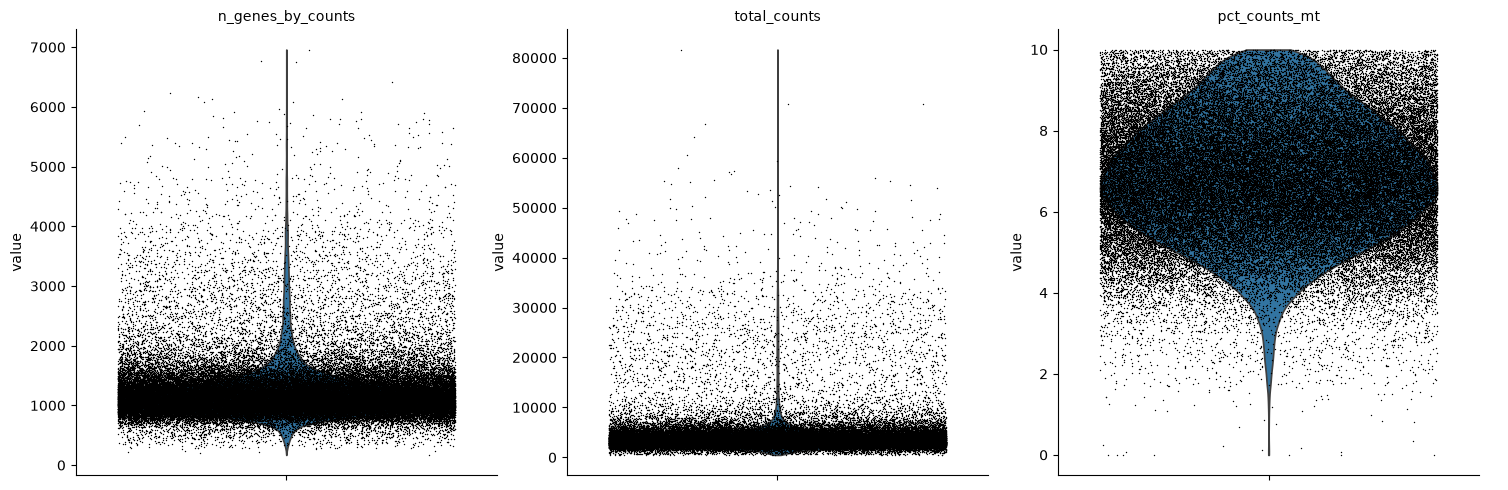

In [15]:
sc.pl.violin(
  mdata['gex'],
  ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
  jitter=0.4,
  multi_panel=True,
)

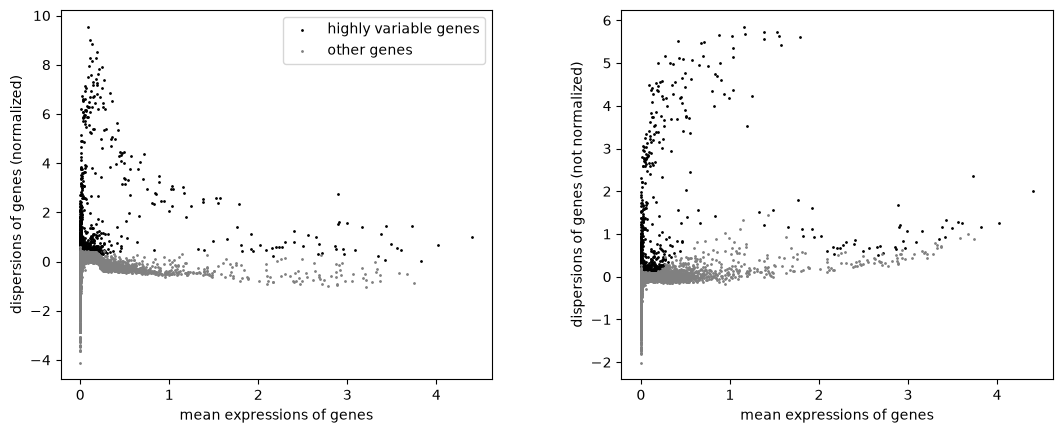

In [16]:
adata = mdata['gex']
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
sc.pl.highly_variable_genes(adata)

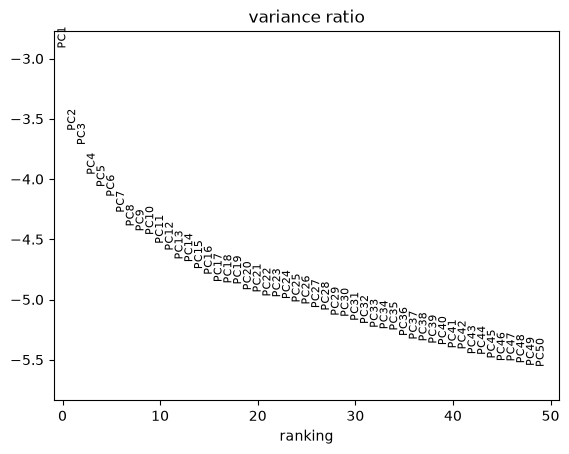

In [17]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

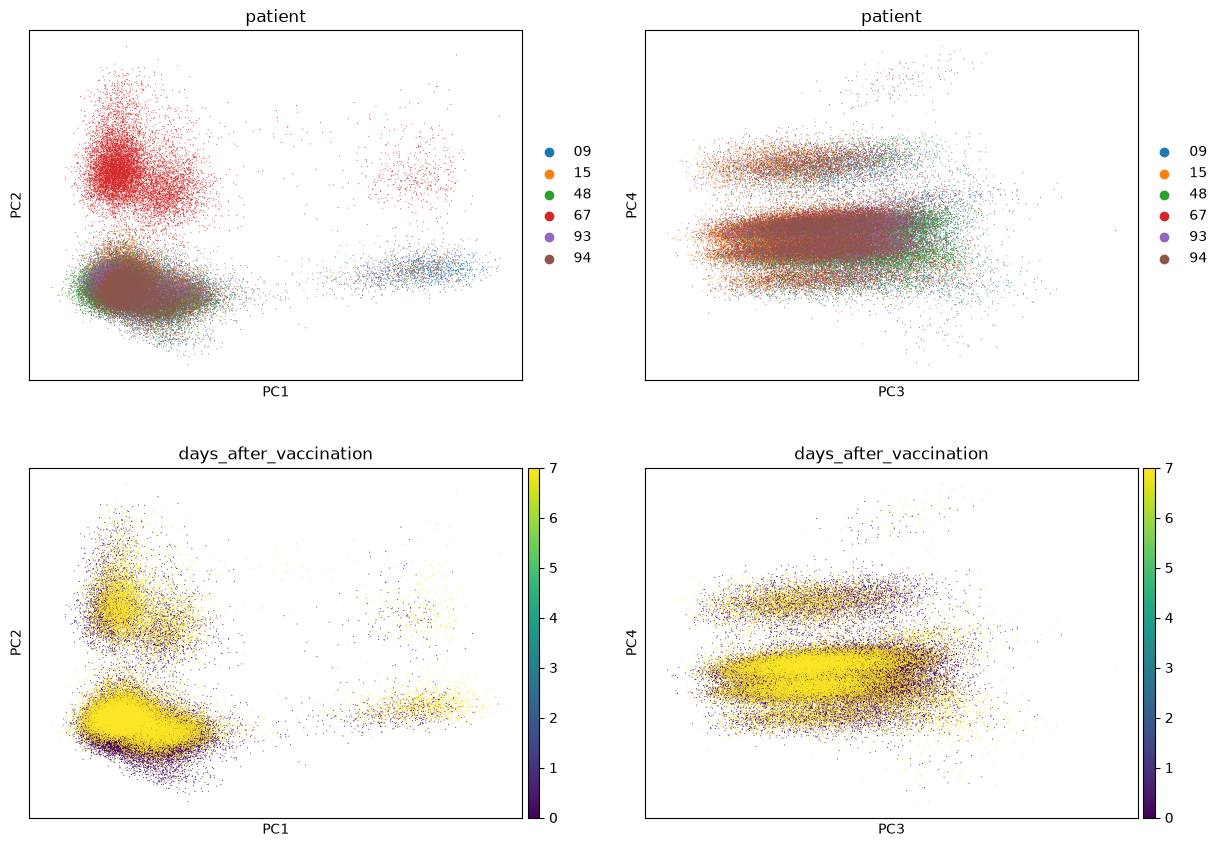

In [18]:
sc.pl.pca(
  mdata['gex'],
  color=["patient", "patient", "days_after_vaccination", "days_after_vaccination"],
  dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
  ncols=2,
  size=2,
)

In [19]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

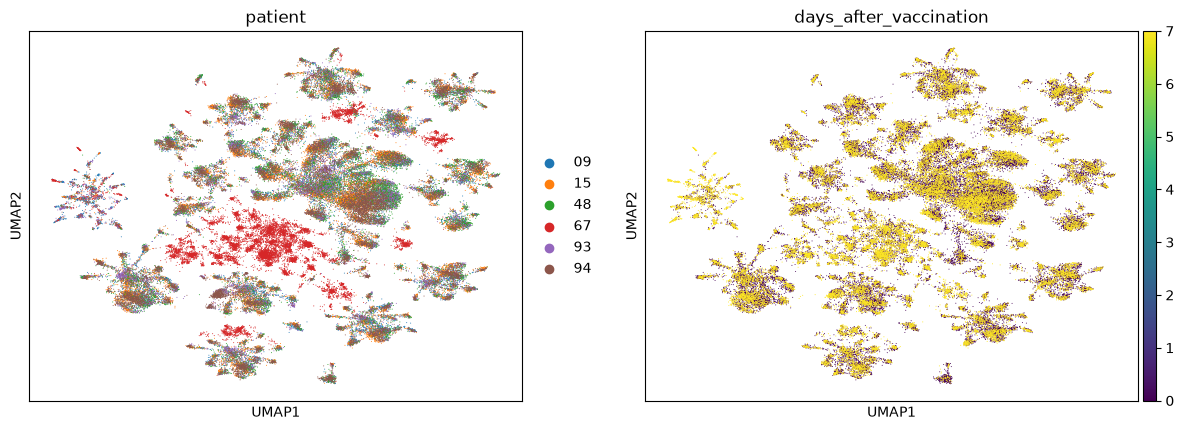

In [20]:
sc.pl.umap(
  adata,
  color=["patient", "days_after_vaccination"],
  size=2,
)

In [21]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")
ir.tl.clonotype_network(mdata, min_cells=2)


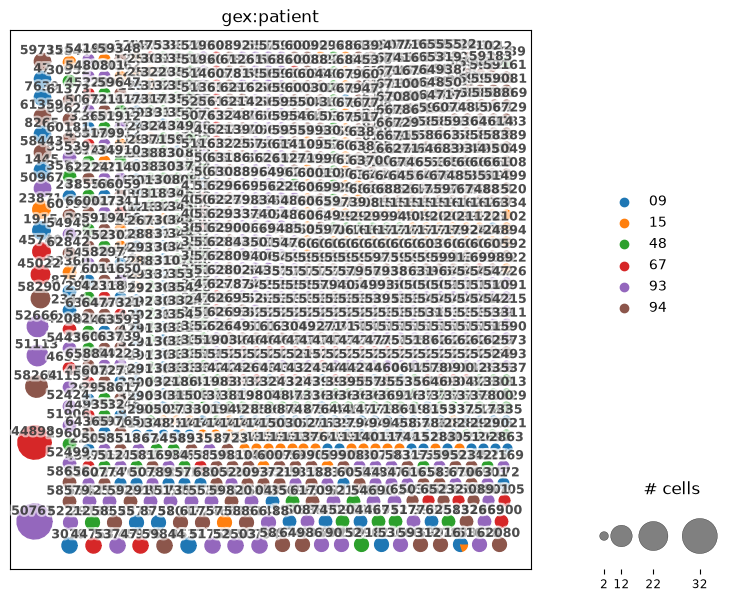

In [22]:
_ = ir.pl.clonotype_network(mdata, color="gex:patient", base_size=20, label_fontsize=9, panel_size=(7, 7))

In [23]:
ir.pp.ir_dist(
    mdata,
    metric="tcrdist",
    sequence="aa",
    cutoff=15,
    # base_matrix="tcrblosum",
)
ir.tl.define_clonotype_clusters(mdata, sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")
ir.tl.clonotype_network(mdata, min_cells=3, sequence="aa", metric="tcrdist")

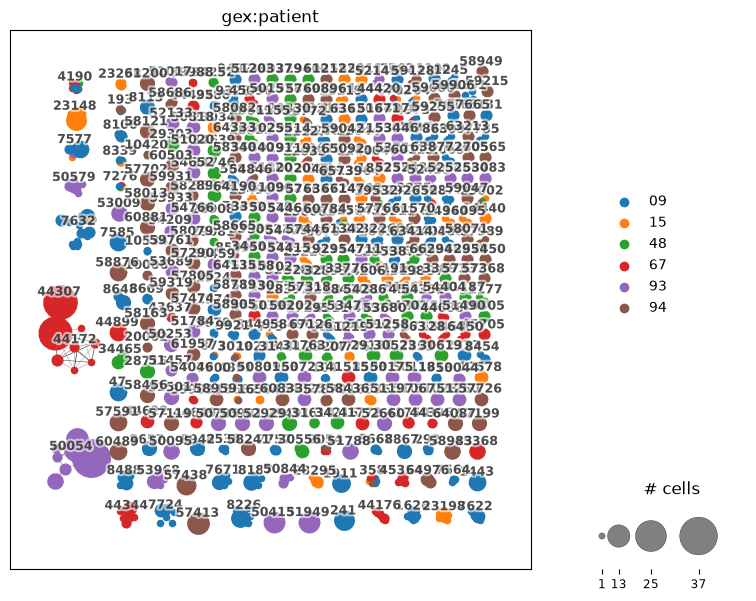

In [24]:
_ = ir.pl.clonotype_network(mdata, color="gex:patient", label_fontsize=9, panel_size=(7, 7), base_size=20)

In [25]:
mdata['airr'].obs.sort_values('clone_id_size', ascending=False)

,receptor_type,receptor_subtype,chain_pairing,age,days_after_vaccination,patient,sample,sex,young,clone_id,clone_id_size,cc_aa_tcrdist,cc_aa_tcrdist_size
cell_id,,,,,,,,,,,,,
TCTATTGGTCTCCCTA-1_93-0,BCR,IGH+IGK,single pair,92,0,93,93-0,female,False,50767,32,50054,78
CGATTGAAGCGTAGTG-1_93-7,BCR,IGH+IGK,single pair,92,7,93,93-7,female,False,50767,32,50054,78
AGGGATGGTGTCAATC-1_93-0,BCR,IGH+IGK,single pair,92,0,93,93-0,female,False,50767,32,50054,78
TGGCTGGTCGCCATAA-1_93-0,BCR,IGH+IGK,single pair,92,0,93,93-0,female,False,50767,32,50054,78
ACGAGCCGTTGTCTTT-1_93-7,BCR,IGH+IGK,single pair,92,7,93,93-7,female,False,50767,32,50054,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...
AGGGAGTAGACGACGT-1_15-7,BCR,IGH+IGK,single pair,29,7,15,15-7,male,True,23976,1,23639,1
AGGGAGTAGACTTTCG-1_15-7,BCR,IGH+IGK,single pair,29,7,15,15-7,male,True,23977,1,23640,1
AGGGAGTAGGGATACC-1_15-7,BCR,IGH+IGL,single pair,29,7,15,15-7,male,True,23978,1,23641,1


In [26]:
with ir.get.airr_context(mdata, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    cdr3_ct_50767 = (
        mdata.obs.loc[lambda x: x["airr:clone_id"] == "50767"]
        .astype(str)
        .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
cdr3_ct_50767

,VJ_1_junction_aa,VDJ_1_junction_aa,VJ_2_junction_aa,VDJ_2_junction_aa,airr:receptor_subtype,n_cells
0,CQQYGSLPRSF,CARGGSRRLRSGSFPPYYFDYW,NaN,NaN,IGH+IGK,32


In [27]:
ir.tl.clonal_expansion(mdata, breakpoints=(1, 2, 5))

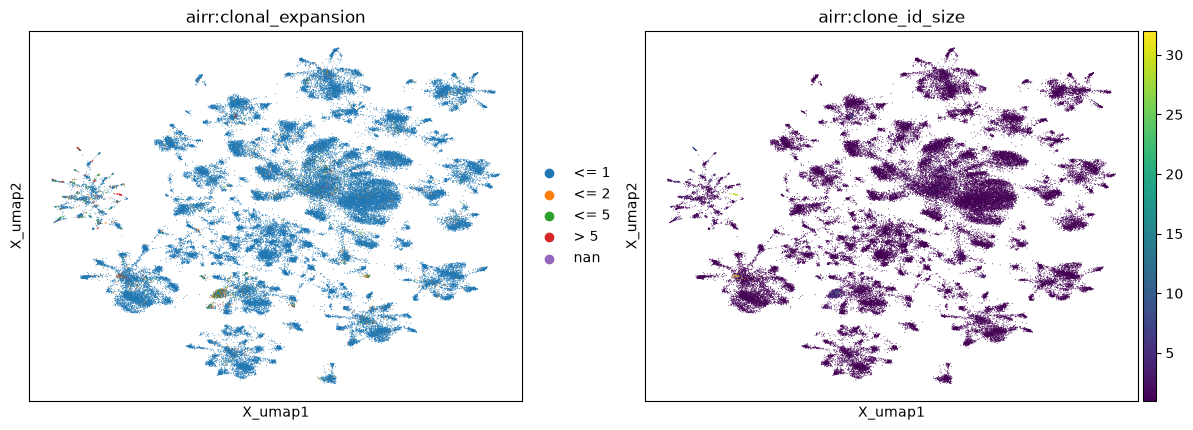

In [28]:
mu.pl.embedding(mdata, basis="gex:umap", color=["airr:clonal_expansion", "airr:clone_id_size"])

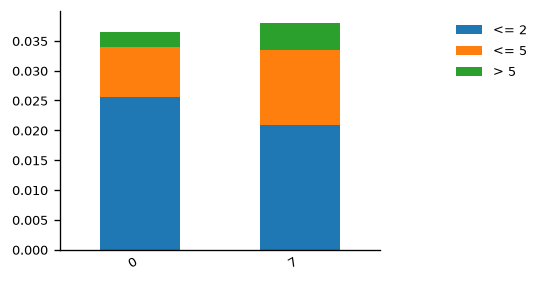

In [29]:
_ = ir.pl.clonal_expansion(mdata, target_col="clone_id", groupby="gex:days_after_vaccination", breakpoints=(1, 2, 5), normalize=True, show_nonexpanded=False)

In [30]:
obs = mdata['airr'].obs
pd.crosstab(obs['clonal_expansion'], obs['days_after_vaccination'])

days_after_vaccination,0,7
clonal_expansion,,
<= 1,38807,30633
<= 2,1031,663
<= 5,338,401
> 5,99,148


In [31]:
def compare_expansion(df1, df2):
  expansion_df1 = (df1['clonal_expansion'] != '<= 1').mean()
  expansion_df2 = (df2['clonal_expansion'] != '<= 1').mean()

  return expansion_df1, expansion_df2

In [32]:
expansion_day_0, expansion_day_7 = compare_expansion(
  obs[obs['days_after_vaccination'] == 0],
  obs[obs['days_after_vaccination'] == 7],
)

print(f"Day 0 expansion: {expansion_day_0:.4f}, day 7 expansion: {expansion_day_7:.4f}")

Day 0 expansion: 0.0364, day 7 expansion: 0.0381


In [33]:
expansion_day_0, expansion_day_7 = compare_expansion(
  obs[(obs['days_after_vaccination'] == 0) & (obs['young'] == True)],
  obs[(obs['days_after_vaccination'] == 7) & (obs['young'] == True)],
)

young_clonal_expansion_rate = expansion_day_7 / expansion_day_0

print(f"Young: Day 0 expansion: {expansion_day_0:.4f}, day 7 expansion: {expansion_day_7:.4f}")
print(f"Rate of expansion: {young_clonal_expansion_rate}")

Young: Day 0 expansion: 0.0144, day 7 expansion: 0.0266
Rate of expansion: 1.8465617862667874


In [34]:
expansion_day_0, expansion_day_7 = compare_expansion(
  obs[(obs['days_after_vaccination'] == 0) & (obs['young'] == False)],
  obs[(obs['days_after_vaccination'] == 7) & (obs['young'] == False)],
)

print(f"Old: Day 0 expansion: {expansion_day_0:4f}, day 7 expansion: {expansion_day_7:4f}")

Old: Day 0 expansion: 0.064776, day 7 expansion: 0.051395


In [35]:
output = {
  "n_cells_all": n_cells_all,
  "outstanding_patient": 67,
  "largest_clonotypes": [67, 93],
  "vdj1_junction_aa": "CARGGSRRLRSGSFPPYYFDYW",
  "larger_clonal_expansion": "post-vaccination",
  "young_clonal_expansion_rate": young_clonal_expansion_rate
}

print(json.dumps(output, indent=2))

# with open('output.json', 'w') as f:
#     json.dump(output, f, indent=2)
# print('Results saved to output.json:')

{
  "n_cells_all": 104527,
  "outstanding_patient": 67,
  "largest_clonotypes": [
    67,
    93
  ],
  "vdj1_junction_aa": "CARGGSRRLRSGSFPPYYFDYW",
  "larger_clonal_expansion": "post-vaccination",
  "young_clonal_expansion_rate": 1.8465617862667874
}
